# NERVE Cross-Sensor Mapping

NERVE aligns **space** (intrinsics, distortion, extrinsics in the mapping JSON files) and **time** (`timings.json` and empirical offsets inside tooling) so that labels and sensor data can be related across RGB, event cameras, and radar.

In [4]:
from nerve import config, remote
from nerve.registry import all_sessions
from pathlib import Path

sessions = all_sessions()
smallest = min(sessions, key=lambda s: s.size_bytes)
print(f"Smallest session: {smallest.name}  "
      f"({smallest.size_bytes / 1e9:.2f} GB archive, split={smallest.split})")

session_dir = Path(remote.download_session(smallest.name))
print(f"Session directory: {session_dir}")


Smallest session: 2023-10-26_15-37-59  (0.40 GB archive, split=train)
  Session already exists: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59
Session directory: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59


## Spatial calibration

Bundled under `nerve.data.mappings`, each JSON describes:

- **src** / **dst** device or camera (with intrinsics and distortion when applicable)
- **src_to_dst** rigid motion (`rot`, `trans`) from source to destination frame

Use `Mapping.from_dict(...)` (see below) for a structured Python object.

In [5]:
import json
from importlib.resources import files
import numpy as np
from nerve.extraction.utils.cameraParams import Mapping

path = files("nerve.data.mappings") / "rgb_to_davis.json"
m = Mapping.from_dict(json.loads(path.read_text(encoding="utf-8")))
print(m)
R = np.array(m.extrinsics.rot_matrix)
T = np.array(m.extrinsics.trans_vector)
print("\nRotation:\n", R)
print("\nTranslation:", T)


Mapping from camera rgb to camera davis:
-----------------------------------------
Source:
-- Camera rgb :--
W x H: (1280, 720)
Intrinsic params:
[[905.03064   0.      653.86414]
 [  0.      905.6657  349.5169 ]
 [  0.        0.        1.     ]]

Distortion type: Standard
Distorsion params:
	k1:	0.14139999449253082
	k2:	0.47049999237060547
	p1:	0.0017000000225380063
	p2:	0.0020000000949949026
	k3:	0.42170000076293945

Destination:
-- Camera davis :--
W x H: (346, 260)
Intrinsic params:
[[ 4.654087e+02 -7.510000e-02  1.810787e+02]
 [ 0.000000e+00  4.652258e+02  1.297596e+02]
 [ 0.000000e+00  0.000000e+00  1.000000e+00]]

Distortion type: Standard
Distorsion params:
	k1:	-0.05510000139474869
	k2:	0.01679999940097332
	p1:	-0.00016460000188089907
	p2:	0.002300000051036477
	k3:	1.1435999870300293

-- Extrinsic params :--
[[ 0.99940002 -0.0057     -0.0338     -0.028257  ]
 [ 0.0039      0.99849999 -0.0545      0.0288121 ]
 [ 0.034       0.0543      0.99790001  0.0410742 ]
 [ 0.          0. 

## How annotations move between sensor spaces

1. Read RGB-space COCO annotations (boxes, keypoints, polygons).
2. For each point, use **source intrinsics + distortion** to form a ray, scale by depth (`avg_distance` / per-point samples in `distance_points`).
3. Apply **extrinsics** to express the 3D point in the destination camera frame.
4. **Project** with destination intrinsics and distortion to get DAVIS or EVK4 pixel coordinates.

For **radar**, which produces 3D point clouds rather than images, the mapping is simpler: apply extrinsics (rotation + translation) to transform radar points into the RGB camera frame, then project via the RGB intrinsics using `mapPoints`.

The NERVE codebase implements this in `nerve.extraction.mapping.mapping_utils` (`mapPixels`, `MapLabels`, `mapPoints`).

### RGB to DAVIS mapping

The first example shows RGB annotations mapped to the DAVIS346 event camera (346x260, standard distortion). The 3-panel figure shows: (1) the original RGB-domain annotation, (2) the stored DAVIS-domain annotation alongside accumulated events, and (3) an overlay of the DAVIS field of view projected back into the RGB frame.

RGB bbox:    [465.25604248046875, 340.6168212890625, 183.14553833007812, 288.70220947265625]
Mapped bbox: [64.6, 106.0, 92.0, 141.1]
Stored bbox: [64.6, 106.0, 92.0, 141.1]
Frame 322: 98,076 events in +/-250 ms window


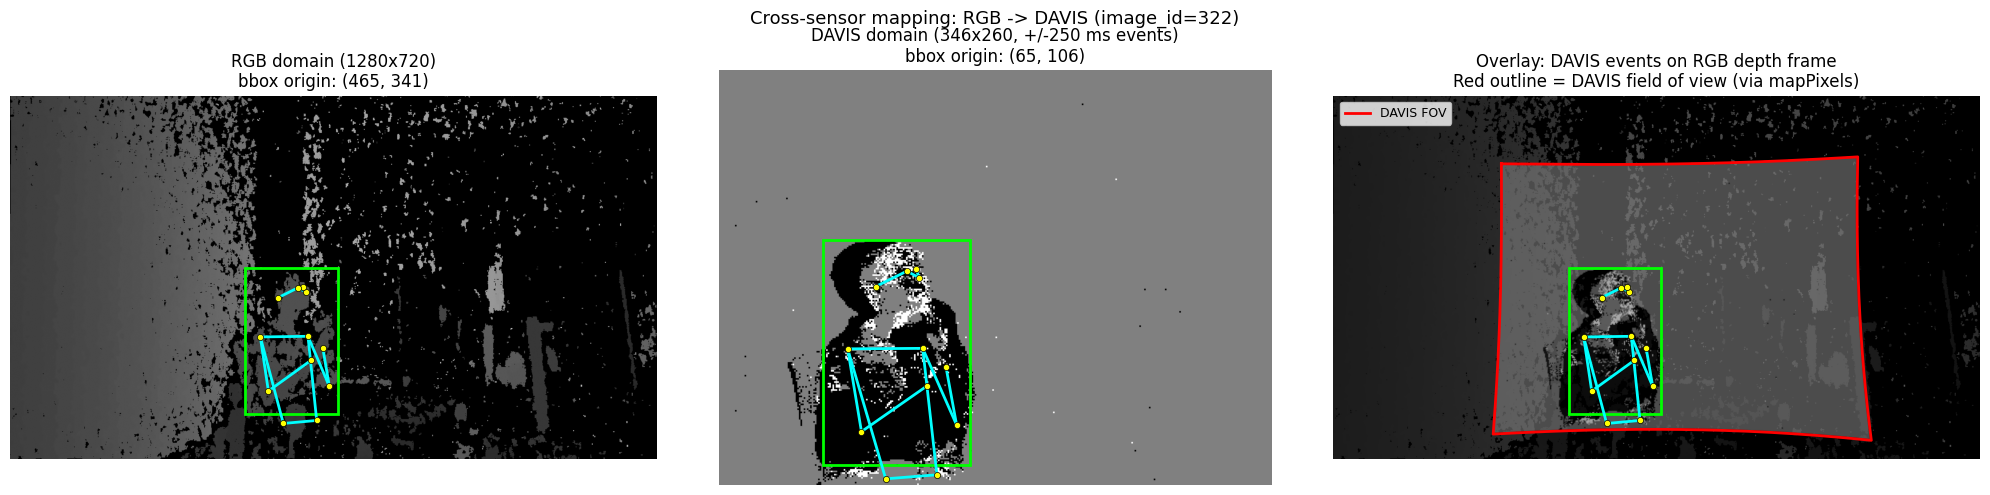

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import h5py
import torch
from importlib.resources import files as _pkg_files
from collections import defaultdict
from nerve.extraction.utils.cameraParams import Mapping
from nerve.extraction.mapping.mapping_utils import mapPixels, MapLabels

# ── Load the bundled rgb_to_davis mapping ──
mapping_dict = json.loads(
    _pkg_files("nerve.data.mappings").joinpath("rgb_to_davis.json")
    .read_text(encoding="utf-8"))
rgb_to_davis = Mapping.from_dict(mapping_dict)

# ── Load annotations from both domains ──
rgb_coco = json.loads(
    (session_dir / "rgb" / "annotations" / "annotations.json").read_text(encoding="utf-8"))
davis_coco_path = session_dir / "davis" / "annotations" / "annotations.json"

if not davis_coco_path.is_file():
    print("No DAVIS annotations -- cannot show cross-sensor mapping.")
else:
    davis_coco = json.loads(davis_coco_path.read_text(encoding="utf-8"))
    cat_by_id = {c["id"]: c["name"] for c in rgb_coco["categories"]}
    rgb_img_by_id = {i["id"]: i for i in rgb_coco["images"]}
    davis_img_by_id = {i["id"]: i for i in davis_coco["images"]}

    rgb_by_img = defaultdict(list)
    for a in rgb_coco["annotations"]:
        rgb_by_img[a["image_id"]].append(a)
    davis_by_img = defaultdict(list)
    for a in davis_coco["annotations"]:
        davis_by_img[a["image_id"]].append(a)

    ev_path = session_dir / "davis" / "events.hdf5"
    with h5py.File(ev_path, "r") as f:
        ev = f["events"]
        W_d, H_d = int(ev.attrs["width"]), int(ev.attrs["height"])
        t_all = ev["t"][:]
    ev_start_us = t_all[0]

    # ── Pick frame with person keypoints in both + most events ──
    shared = set(rgb_by_img) & set(davis_by_img)
    best_id, best_n = None, 0
    for iid in sorted(shared):
        rp = [a for a in rgb_by_img[iid] if a.get("keypoints") and a.get("category_id") == 1]
        dp = [a for a in davis_by_img[iid] if a.get("keypoints") and a.get("category_id") == 1]
        if not (rp and dp):
            continue
        abs_t = davis_img_by_id[iid]["time_ms"] * 1000 + ev_start_us
        lo = np.searchsorted(t_all, abs_t - 250_000)
        hi = np.searchsorted(t_all, abs_t + 250_000)
        if hi - lo > best_n:
            best_n = hi - lo
            best_id = iid

    if best_id is None:
        print("No shared person frame with event coverage found.")
    else:
        rgb_info = rgb_img_by_id[best_id]
        davis_info = davis_img_by_id[best_id]
        rgb_ann = [a for a in rgb_by_img[best_id]
                   if a.get("keypoints") and a.get("category_id") == 1][0]
        davis_ann = [a for a in davis_by_img[best_id]
                     if a.get("keypoints") and a.get("category_id") == 1][0]

        # ── Use MapLabels to re-map the RGB annotation to DAVIS space ──
        mapped_anns = MapLabels([rgb_ann], rgb_to_davis, dst_dataset=[], device=torch.device("cpu"))
        if mapped_anns:
            remapped_ann = mapped_anns[0]
            print(f"RGB bbox:    {rgb_ann['bbox']}")
            print(f"Mapped bbox: {[round(v, 1) for v in remapped_ann['bbox']]}")
            print(f"Stored bbox: {[round(v, 1) for v in davis_ann['bbox']]}")

        # ── Construct the inverse mapping (DAVIS -> RGB) so we can use mapPixels ──
        from nerve.extraction.utils.cameraParams import ExtrinsicParams
        R = rgb_to_davis.extrinsics.rot_matrix
        T = rgb_to_davis.extrinsics.trans_vector
        davis_to_rgb = Mapping(rgb_to_davis.dst, rgb_to_davis.src,
                               ExtrinsicParams(R.T, -R.T @ T))
        # Assumed scene depth (metres) for the re-projection. mapPixels needs a depth
        # to apply the translation component of the extrinsics (parallax). The exact
        # value is not critical here because the inter-camera baseline is only a few cm;
        # 3 m is a representative indoor distance to the subjects.
        depth = 3.0

        # ── Dense FOV boundary (many points per edge for distortion accuracy) ──
        N = 50
        top    = np.stack([np.linspace(0, W_d, N), np.zeros(N)])
        right  = np.stack([np.full(N, W_d),        np.linspace(0, H_d, N)])
        bottom = np.stack([np.linspace(W_d, 0, N), np.full(N, H_d)])
        left   = np.stack([np.zeros(N),            np.linspace(H_d, 0, N)])
        border = np.hstack([top, right, bottom, left])
        fov_rgb, _, _ = mapPixels(border, davis_to_rgb, distance=depth,
                                  clamp_to_dest_POV=False)
        fov_x, fov_y = fov_rgb[0], fov_rgb[1]

        # ── Depth frame as RGB-domain background ──
        depth_mp4 = session_dir / "L515_depth.mp4"
        cap = cv2.VideoCapture(str(depth_mp4))
        depth_fps = cap.get(cv2.CAP_PROP_FPS)
        fidx = int(round(rgb_info["time_ms"] * depth_fps / 1000.0))
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ok, bgr = cap.read()
        cap.release()
        depth_bg = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if ok else np.zeros(
            (rgb_info["height"], rgb_info["width"]), dtype=np.uint8)

        # ── Accumulated DAVIS events (+/-250 ms) ──
        abs_t = davis_info["time_ms"] * 1000 + ev_start_us
        with h5py.File(ev_path, "r") as f:
            ev = f["events"]
            lo = np.searchsorted(t_all, abs_t - 250_000)
            hi = np.searchsorted(t_all, abs_t + 250_000)
            chunk = ev[lo:hi]
        davis_frame = np.full((H_d, W_d, 3), 128, dtype=np.uint8)
        if len(chunk) > 0:
            xs, ys, ps = chunk["x"], chunk["y"], chunk["p"]
            davis_frame[ys[ps > 0], xs[ps > 0]] = [255, 255, 255]
            davis_frame[ys[ps <= 0], xs[ps <= 0]] = [0, 0, 0]
        print(f"Frame {best_id}: {len(chunk):,} events in +/-250 ms window")

        # ── Skeleton drawing helper ──
        EDGES = [
            (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
            (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
        ]

        def draw_ann(ax, ann, color="lime", kp_thresh=0.5):
            bx, by, bw, bh = ann["bbox"]
            ax.add_patch(patches.Rectangle((bx, by), bw, bh,
                         fill=False, edgecolor=color, linewidth=2))
            kps = ann.get("keypoints")
            if kps and len(kps) >= 3:
                kps = np.array(kps, dtype=float).reshape(-1, 3)
                for i, j in EDGES:
                    if kps[i, 2] > kp_thresh and kps[j, 2] > kp_thresh:
                        ax.plot([kps[i, 0], kps[j, 0]], [kps[i, 1], kps[j, 1]],
                                "-", color="cyan", linewidth=2)
                vis = kps[:, 2] > kp_thresh
                ax.scatter(kps[vis, 0], kps[vis, 1], c="yellow", s=20,
                           edgecolors="k", linewidths=0.5, zorder=5)

        # ── 3-panel figure ──
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        axes[0].imshow(depth_bg, cmap="gray")
        draw_ann(axes[0], rgb_ann)
        axes[0].set_title(f"RGB domain ({rgb_info['width']}x{rgb_info['height']})\n"
                          f"bbox origin: ({rgb_ann['bbox'][0]:.0f}, {rgb_ann['bbox'][1]:.0f})")
        axes[0].axis("off")

        axes[1].imshow(davis_frame)
        draw_ann(axes[1], davis_ann)
        axes[1].set_title(f"DAVIS domain ({W_d}x{H_d}, +/-250 ms events)\n"
                          f"bbox origin: ({davis_ann['bbox'][0]:.0f}, {davis_ann['bbox'][1]:.0f})")
        axes[1].axis("off")

        # ── Per-pixel warp using mapPixels (forward: RGB -> DAVIS) ──
        from nerve.extraction.mapping.mapping_utils import overlapImageToBackground
        H_rgb, W_rgb = rgb_info["height"], rgb_info["width"]
        gy, gx = np.mgrid[0:H_rgb, 0:W_rgb]
        rgb_grid = np.stack([gx.ravel().astype(np.float32),
                             gy.ravel().astype(np.float32)])
        dst_grid, _, _ = mapPixels(rgb_grid, rgb_to_davis, distance=depth,
                                   clamp_to_dest_POV=False)
        map_x = dst_grid[0].reshape(H_rgb, W_rgb).astype(np.float32)
        map_y = dst_grid[1].reshape(H_rgb, W_rgb).astype(np.float32)
        in_fov = ((map_x >= 0) & (map_x < W_d) &
                  (map_y >= 0) & (map_y < H_d))
        map_x[~in_fov] = -1
        map_y[~in_fov] = -1
        warped = cv2.remap(davis_frame, map_x, map_y,
                           cv2.INTER_LINEAR, borderValue=(0, 0, 0))
        opacity = (in_fov.astype(np.float32) * 0.6 * 255).astype(np.uint8)
        overlay = overlapImageToBackground(warped,  opacity,
                                           cv2.cvtColor(depth_bg, cv2.COLOR_GRAY2RGB))

        axes[2].imshow(overlay)
        axes[2].plot(fov_x, fov_y, "-", color="red", linewidth=2, label="DAVIS FOV")
        draw_ann(axes[2], rgb_ann, color="lime")
        axes[2].legend(loc="upper left", fontsize=9)
        axes[2].set_title("Overlay: DAVIS events on RGB depth frame\n"
                          "Red outline = DAVIS field of view (via mapPixels)")
        axes[2].axis("off")

        plt.suptitle(f"Cross-sensor mapping: RGB -> DAVIS (image_id={best_id})",
                     fontsize=13)
        plt.tight_layout()
        plt.show()


### RGB to Prophesee (EVK4) mapping

The same spatial calibration pipeline applies to the Prophesee EVK4 event camera (1280x720, fisheye lens). Because the EVK4 uses a **fisheye distortion model** (4 coefficients: k1--k4), `mapPixels` and `MapLabels` automatically switch to `cv2.fisheye.projectPoints` for the destination projection step.

RGB bbox:    [465.25604248046875, 340.6168212890625, 183.14553833007812, 288.70220947265625]
Mapped bbox: [315.5, 339.6, 263.2, 379.4]
Stored bbox: [315.5, 339.6, 263.2, 379.4]
Frame 322: 984,747 EVK4 events in +/-250 ms window


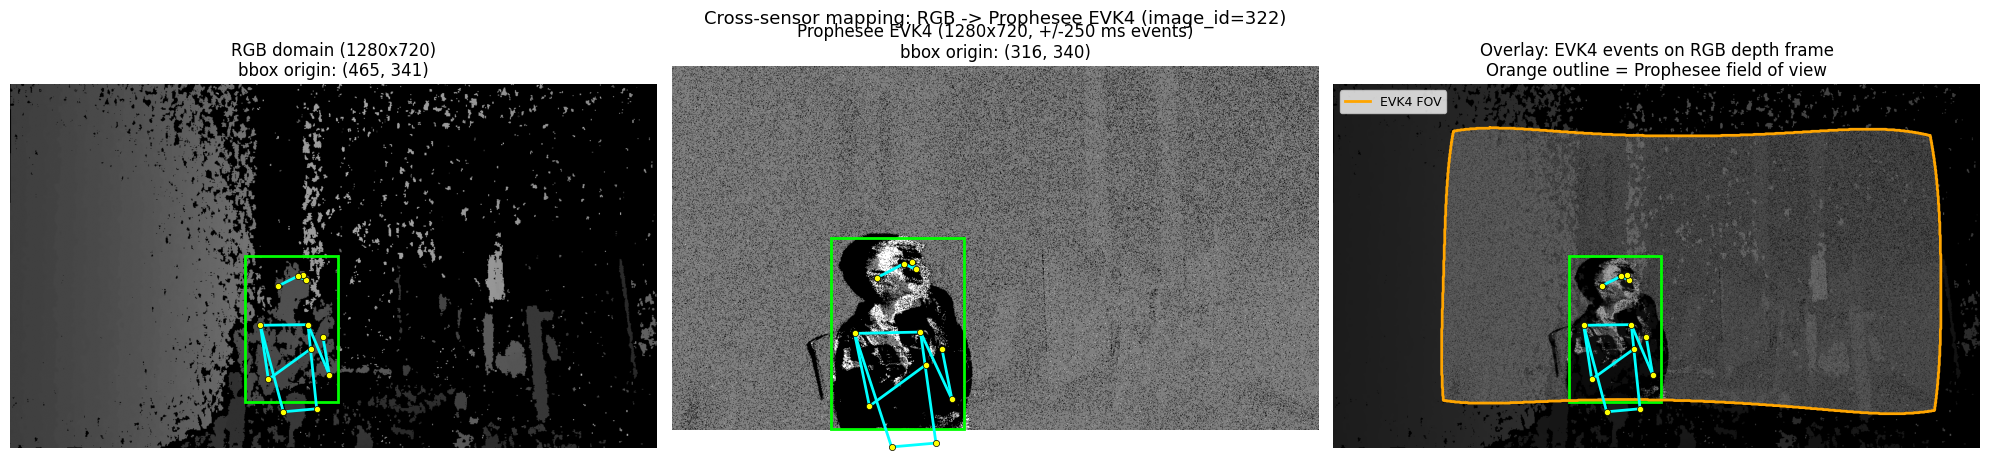

In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import h5py
import torch
from importlib.resources import files as _pkg_files
from collections import defaultdict
from nerve.extraction.utils.cameraParams import Mapping
from nerve.extraction.mapping.mapping_utils import mapPixels, MapLabels

# ── Load the bundled rgb_to_prophesee mapping ──
prop_mapping_dict = json.loads(
    _pkg_files("nerve.data.mappings").joinpath("rgb_to_prophesee.json")
    .read_text(encoding="utf-8"))
rgb_to_prop = Mapping.from_dict(prop_mapping_dict)

# ── Load annotations from both domains ──
rgb_coco = json.loads(
    (session_dir / "rgb" / "annotations" / "annotations.json").read_text(encoding="utf-8"))
prop_coco_path = session_dir / "prophesee" / "annotations" / "annotations.json"

if not prop_coco_path.is_file():
    print("No Prophesee annotations -- cannot show cross-sensor mapping.")
else:
    prop_coco = json.loads(prop_coco_path.read_text(encoding="utf-8"))
    rgb_img_by_id = {i["id"]: i for i in rgb_coco["images"]}
    prop_img_by_id = {i["id"]: i for i in prop_coco["images"]}

    rgb_by_img = defaultdict(list)
    for a in rgb_coco["annotations"]:
        rgb_by_img[a["image_id"]].append(a)
    prop_by_img = defaultdict(list)
    for a in prop_coco["annotations"]:
        prop_by_img[a["image_id"]].append(a)

    evk4_path = session_dir / "evk4_events.hdf5"
    if not evk4_path.is_file():
        print("EVK4 events.hdf5 not found.")
    else:
        with h5py.File(evk4_path, "r") as f:
            ev = f["events"]
            W_p, H_p = int(ev.attrs["width"]), int(ev.attrs["height"])
            t_all_p = ev["t"][:]
        ev_start_us_p = t_all_p[0]

        # ── Pick frame with person keypoints in both + most events ──
        shared = set(rgb_by_img) & set(prop_by_img)
        best_id, best_n = None, 0
        for iid in sorted(shared):
            rp = [a for a in rgb_by_img[iid] if a.get("keypoints") and a.get("category_id") == 1]
            dp = [a for a in prop_by_img[iid] if a.get("keypoints") and a.get("category_id") == 1]
            if not (rp and dp):
                continue
            abs_t = prop_img_by_id[iid]["time_ms"] * 1000 + ev_start_us_p
            lo = np.searchsorted(t_all_p, abs_t - 250_000)
            hi = np.searchsorted(t_all_p, abs_t + 250_000)
            if hi - lo > best_n:
                best_n = hi - lo
                best_id = iid

        if best_id is None:
            print("No shared person frame with EVK4 event coverage found.")
        else:
            rgb_info = rgb_img_by_id[best_id]
            prop_info = prop_img_by_id[best_id]
            rgb_ann = [a for a in rgb_by_img[best_id]
                       if a.get("keypoints") and a.get("category_id") == 1][0]
            prop_ann = [a for a in prop_by_img[best_id]
                        if a.get("keypoints") and a.get("category_id") == 1][0]

            # ── Use MapLabels to re-map the RGB annotation to Prophesee space ──
            mapped_anns = MapLabels([rgb_ann], rgb_to_prop, dst_dataset=[], device=torch.device("cpu"))
            if mapped_anns:
                remapped_ann = mapped_anns[0]
                print(f"RGB bbox:    {rgb_ann['bbox']}")
                print(f"Mapped bbox: {[round(v, 1) for v in remapped_ann['bbox']]}")
                print(f"Stored bbox: {[round(v, 1) for v in prop_ann['bbox']]}")

            # Assumed scene depth for re-projection (see DAVIS cell for explanation)
            depth = 3.0

            # ── Depth frame as RGB-domain background ──
            depth_mp4 = session_dir / "L515_depth.mp4"
            cap = cv2.VideoCapture(str(depth_mp4))
            depth_fps = cap.get(cv2.CAP_PROP_FPS)
            fidx = int(round(rgb_info["time_ms"] * depth_fps / 1000.0))
            cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
            ok, bgr = cap.read()
            cap.release()
            depth_bg = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if ok else np.zeros(
                (rgb_info["height"], rgb_info["width"]), dtype=np.uint8)

            # ── Accumulated EVK4 events (+/-250 ms) ──
            abs_t = prop_info["time_ms"] * 1000 + ev_start_us_p
            with h5py.File(evk4_path, "r") as f:
                ev = f["events"]
                lo = np.searchsorted(t_all_p, abs_t - 250_000)
                hi = np.searchsorted(t_all_p, abs_t + 250_000)
                chunk = ev[lo:hi]
            prop_frame = np.full((H_p, W_p, 3), 128, dtype=np.uint8)
            if len(chunk) > 0:
                xs, ys, ps = chunk["x"], chunk["y"], chunk["p"]
                prop_frame[ys[ps > 0], xs[ps > 0]] = [255, 255, 255]
                prop_frame[ys[ps <= 0], xs[ps <= 0]] = [0, 0, 0]
            print(f"Frame {best_id}: {len(chunk):,} EVK4 events in +/-250 ms window")

            # ── Skeleton drawing helper ──
            EDGES = [
                (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
                (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
            ]

            def draw_ann(ax, ann, color="lime", kp_thresh=0.5):
                bx, by, bw, bh = ann["bbox"]
                ax.add_patch(patches.Rectangle((bx, by), bw, bh,
                             fill=False, edgecolor=color, linewidth=2))
                kps = ann.get("keypoints")
                if kps and len(kps) >= 3:
                    kps = np.array(kps, dtype=float).reshape(-1, 3)
                    for i, j in EDGES:
                        if kps[i, 2] > kp_thresh and kps[j, 2] > kp_thresh:
                            ax.plot([kps[i, 0], kps[j, 0]], [kps[i, 1], kps[j, 1]],
                                    "-", color="cyan", linewidth=2)
                    vis = kps[:, 2] > kp_thresh
                    ax.scatter(kps[vis, 0], kps[vis, 1], c="yellow", s=20,
                               edgecolors="k", linewidths=0.5, zorder=5)

            # ── 3-panel figure ──
            fig, axes = plt.subplots(1, 3, figsize=(20, 5))

            axes[0].imshow(depth_bg, cmap="gray")
            draw_ann(axes[0], rgb_ann)
            axes[0].set_title(f"RGB domain ({rgb_info['width']}x{rgb_info['height']})\n"
                              f"bbox origin: ({rgb_ann['bbox'][0]:.0f}, {rgb_ann['bbox'][1]:.0f})")
            axes[0].axis("off")

            axes[1].imshow(prop_frame)
            draw_ann(axes[1], prop_ann)
            axes[1].set_title(f"Prophesee EVK4 ({W_p}x{H_p}, +/-250 ms events)\n"
                              f"bbox origin: ({prop_ann['bbox'][0]:.0f}, {prop_ann['bbox'][1]:.0f})")
            axes[1].axis("off")

            # ── Per-pixel warp using mapPixels (forward: RGB -> Prophesee) ──
            from nerve.extraction.mapping.mapping_utils import overlapImageToBackground
            H_rgb, W_rgb = rgb_info["height"], rgb_info["width"]
            gy, gx = np.mgrid[0:H_rgb, 0:W_rgb]
            rgb_grid = np.stack([gx.ravel().astype(np.float32),
                                 gy.ravel().astype(np.float32)])
            dst_grid, _, _ = mapPixels(rgb_grid, rgb_to_prop, distance=depth,
                                       clamp_to_dest_POV=False)
            map_x = dst_grid[0].reshape(H_rgb, W_rgb).astype(np.float32)
            map_y = dst_grid[1].reshape(H_rgb, W_rgb).astype(np.float32)
            in_fov = ((map_x >= 0) & (map_x < W_p) &
                      (map_y >= 0) & (map_y < H_p))
            map_x[~in_fov] = -1
            map_y[~in_fov] = -1
            warped = cv2.remap(prop_frame, map_x, map_y,
                               cv2.INTER_LINEAR, borderValue=(0, 0, 0))
            opacity = (in_fov.astype(np.float32) * 0.6 * 255).astype(np.uint8)
            overlay = overlapImageToBackground(warped, opacity,
                                               cv2.cvtColor(depth_bg, cv2.COLOR_GRAY2RGB))

            # ── Extract FOV contour from the in_fov mask ──
            fov_contours, _ = cv2.findContours(in_fov.astype(np.uint8),
                                               cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            fov_contour = max(fov_contours, key=cv2.contourArea)
            fov_x = fov_contour[:, 0, 0]
            fov_y = fov_contour[:, 0, 1]

            axes[2].imshow(overlay)
            axes[2].plot(fov_x, fov_y, "-", color="orange", linewidth=2, label="EVK4 FOV")
            draw_ann(axes[2], rgb_ann, color="lime")
            axes[2].legend(loc="upper left", fontsize=9)
            axes[2].set_title("Overlay: EVK4 events on RGB depth frame\n"
                              "Orange outline = Prophesee field of view")
            axes[2].axis("off")

            plt.suptitle(f"Cross-sensor mapping: RGB -> Prophesee EVK4 (image_id={best_id})",
                         fontsize=13)
            plt.tight_layout()
            plt.show()

### TI radar to RGB mapping

The TI mmWave radar is a non-imaging sensor -- it produces 3D point clouds (x, y, z in metres) rather than a pixel grid. The `ti_radar_to_rgb` mapping therefore contains **only extrinsics** (identity rotation + a small translation offset reflecting the physical mounting distance between the radar and the RGB camera). To project radar detections into the RGB image, `mapPoints` applies the extrinsics and then projects through the RGB camera's intrinsics and distortion model.

Two visualizations are shown below:

1. **Parallax effect:** Two person-sized point clusters (at 3 m and 5 m depth) are projected into the RGB image *with* and *without* the translation offset. The yellow arrows show how the few-centimetre physical offset between radar and camera shifts each point's pixel position -- the shift is larger for closer objects (parallax).

2. **Perspective projection:** A regular 3D grid at three depth planes (2 m, 3 m, 5 m) is projected via `mapPoints`. Closer planes spread wider across the image (perspective foreshortening), while farther planes cluster toward the centre.

Translation [x, y, z] (metres): [ 0.14  -0.065 -0.06 ]
  The radar sits 14.0 cm to the right, 6.5 cm above, and 6.0 cm in front of the RGB camera.
  Rotation is identity -- both sensors face the same direction.



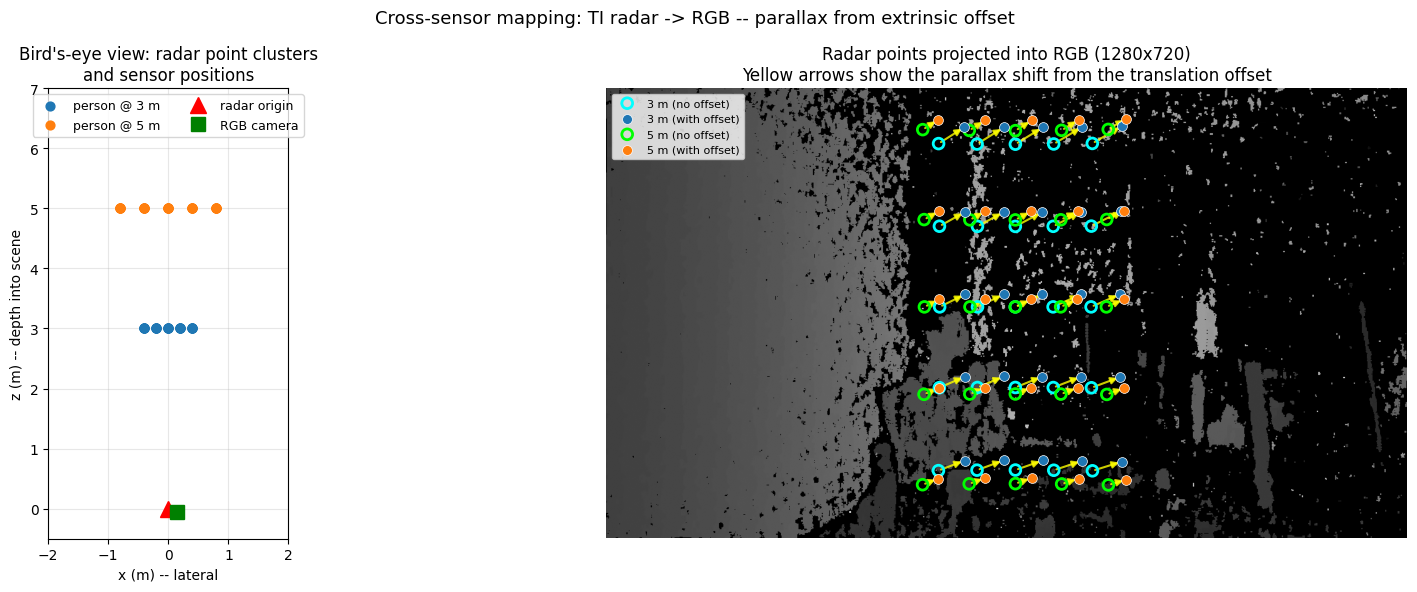

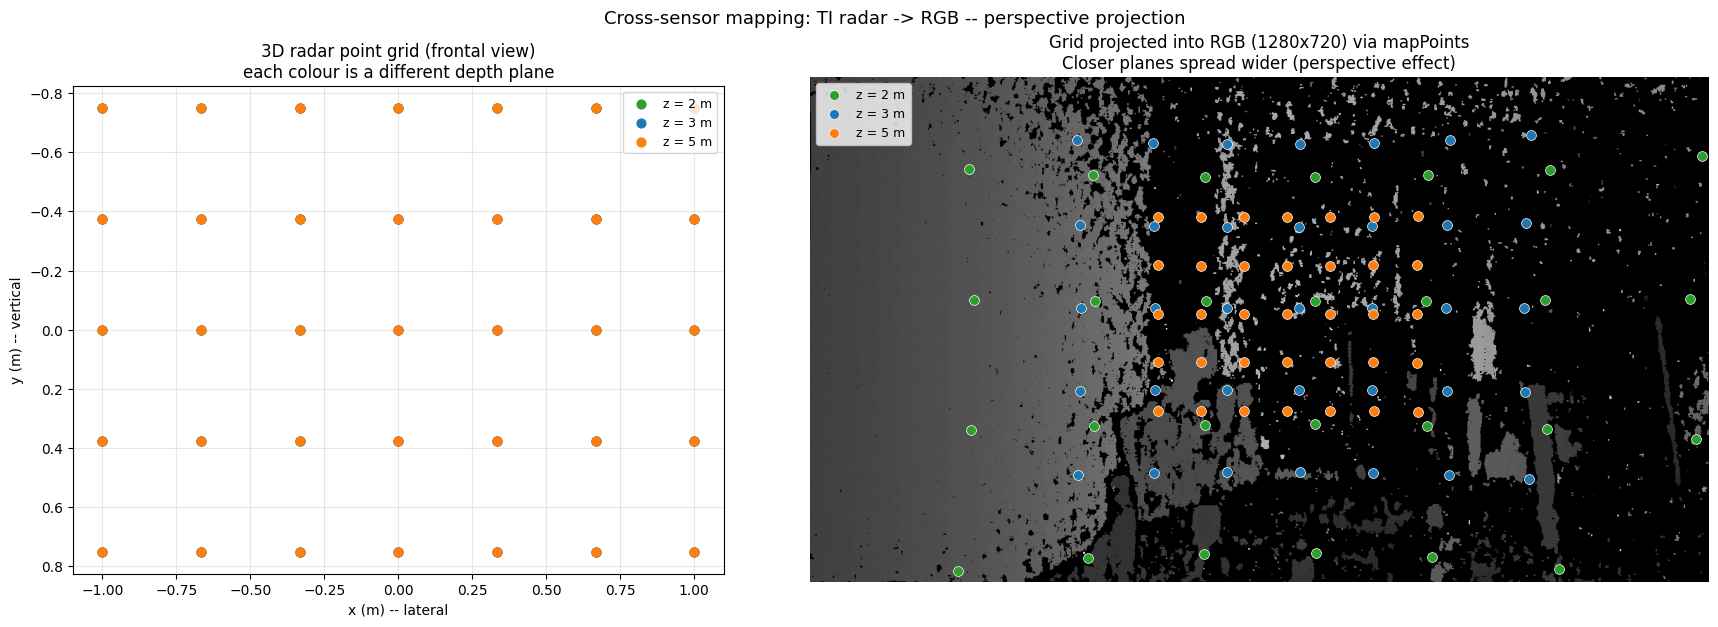

In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from importlib.resources import files as _pkg_files
from nerve.extraction.utils.cameraParams import Mapping, ExtrinsicParams
from nerve.extraction.mapping.mapping_utils import mapPoints

# ── Load the bundled ti_radar_to_rgb mapping ──
radar_mapping_dict = json.loads(
    _pkg_files("nerve.data.mappings").joinpath("ti_radar_to_rgb.json")
    .read_text(encoding="utf-8"))
ti_to_rgb = Mapping.from_dict(radar_mapping_dict)

T = ti_to_rgb.extrinsics.trans_vector
print(f"Translation [x, y, z] (metres): {T}")
print(f"  The radar sits {T[0]*100:.1f} cm to the right, "
      f"{abs(T[1])*100:.1f} cm above, and "
      f"{abs(T[2])*100:.1f} cm in front of the RGB camera.")
print(f"  Rotation is identity -- both sensors face the same direction.\n")

# ── Load an RGB-domain background frame ──
rgb_coco = json.loads(
    (session_dir / "rgb" / "annotations" / "annotations.json").read_text(encoding="utf-8"))
mid_img = rgb_coco["images"][len(rgb_coco["images"]) // 2]
depth_mp4 = session_dir / "L515_depth.mp4"
cap = cv2.VideoCapture(str(depth_mp4))
depth_fps = cap.get(cv2.CAP_PROP_FPS)
fidx = int(round(mid_img["time_ms"] * depth_fps / 1000.0))
cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
ok, bgr = cap.read()
cap.release()
depth_bg = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if ok else np.zeros(
    (mid_img["height"], mid_img["width"]), dtype=np.uint8)
W, H = mid_img["width"], mid_img["height"]

# ═══════════════════════════════════════════════════════════════════
# Figure 1: Parallax effect -- how the translation offset shifts
# radar points when projected into the RGB image.
# ═══════════════════════════════════════════════════════════════════
person_x = np.linspace(-0.4, 0.4, 5)
person_y = np.linspace(-0.85, 0.85, 5)
person_pts = np.array([[x, y, 3.0] for y in person_y for x in person_x],
                       dtype=np.float32)
far_pts = person_pts.copy()
far_pts[:, 2] = 5.0
far_pts[:, 0] *= 2.0
far_pts[:, 1] *= 1.8

all_pts = np.vstack([person_pts, far_pts])
mask3 = np.arange(len(all_pts)) < len(person_pts)
mask5 = ~mask3

pixels_2d, distances = mapPoints(all_pts, ti_to_rgb)

no_offset = Mapping(ti_to_rgb.src, ti_to_rgb.dst,
                    ExtrinsicParams(ti_to_rgb.extrinsics.rot_matrix,
                                    np.zeros(3, dtype=np.float32)))
pixels_no_T, _ = mapPoints(all_pts, no_offset)

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                         gridspec_kw={"width_ratios": [1, 1.6]})

# Panel 1: bird's-eye view
ax = axes[0]
ax.scatter(all_pts[mask3, 0], all_pts[mask3, 2], s=40, c="tab:blue",
           label="person @ 3 m", zorder=3)
ax.scatter(all_pts[mask5, 0], all_pts[mask5, 2], s=40, c="tab:orange",
           label="person @ 5 m", zorder=3)
ax.plot(0, 0, "^", color="red", markersize=12, label="radar origin")
ax.plot(T[0], T[2], "s", color="green", markersize=10, label="RGB camera")
ax.set_xlabel("x (m) -- lateral")
ax.set_ylabel("z (m) -- depth into scene")
ax.set_title("Bird's-eye view: radar point clusters\nand sensor positions")
ax.legend(fontsize=9, loc="upper center", ncol=2)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 2)
ax.set_ylim(-0.5, 7)

# Panel 2: projected onto RGB image
ax = axes[1]
ax.imshow(depth_bg, cmap="gray")
px, py = pixels_2d[:, 0], pixels_2d[:, 1]
px0, py0 = pixels_no_T[:, 0], pixels_no_T[:, 1]

for i in range(len(all_pts)):
    ax.annotate("", xy=(px[i], py[i]), xytext=(px0[i], py0[i]),
                arrowprops=dict(arrowstyle="-|>", color="yellow",
                                lw=1.5, alpha=0.8, mutation_scale=10))

ax.scatter(px0[mask3], py0[mask3], s=60, facecolors="none", edgecolors="cyan",
           linewidths=2, label="3 m (no offset)", zorder=5)
ax.scatter(px[mask3], py[mask3], s=50, c="tab:blue",
           edgecolors="white", linewidths=0.5, label="3 m (with offset)", zorder=6)
ax.scatter(px0[mask5], py0[mask5], s=60, facecolors="none", edgecolors="lime",
           linewidths=2, label="5 m (no offset)", zorder=5)
ax.scatter(px[mask5], py[mask5], s=50, c="tab:orange",
           edgecolors="white", linewidths=0.5, label="5 m (with offset)", zorder=6)

ax.set_xlim(0, W)
ax.set_ylim(H, 0)
ax.legend(fontsize=8, loc="upper left")
ax.set_title(f"Radar points projected into RGB ({W}x{H})\n"
             "Yellow arrows show the parallax shift from the translation offset")
ax.axis("off")

plt.suptitle("Cross-sensor mapping: TI radar -> RGB -- parallax from extrinsic offset",
             fontsize=13)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# Figure 2: General projection -- a regular 3D grid at three depths
# projected into the RGB image, showing how perspective makes closer
# points spread wider and farther points cluster toward the centre.
# ═══════════════════════════════════════════════════════════════════
xs = np.linspace(-1.0, 1.0, 7)
ys = np.linspace(-0.75, 0.75, 5)
zs = np.array([2.0, 3.0, 5.0])
grid = np.array([[x, y, z] for z in zs for y in ys for x in xs], dtype=np.float32)
grid_pix, grid_dist = mapPoints(grid, ti_to_rgb)

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6),
                            gridspec_kw={"width_ratios": [1, 1.6]})

# Panel 1: frontal view (x vs y) with depth colour
ax = axes2[0]
colors = {2.0: "tab:green", 3.0: "tab:blue", 5.0: "tab:orange"}
for z in zs:
    m = grid[:, 2] == z
    ax.scatter(grid[m, 0], grid[m, 1], s=40, c=colors[z],
               label=f"z = {z:.0f} m", zorder=3)
ax.set_xlabel("x (m) -- lateral")
ax.set_ylabel("y (m) -- vertical")
ax.set_title("3D radar point grid (frontal view)\neach colour is a different depth plane")
ax.legend(fontsize=9)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.invert_yaxis()

# Panel 2: projected onto RGB image
ax = axes2[1]
ax.imshow(depth_bg, cmap="gray")
gx, gy = grid_pix[:, 0], grid_pix[:, 1]
in_frame = (gx >= 0) & (gx < W) & (gy >= 0) & (gy < H)
for z in zs:
    m = (grid[:, 2] == z) & in_frame
    ax.scatter(gx[m], gy[m], s=50, c=colors[z], edgecolors="white",
               linewidths=0.5, label=f"z = {z:.0f} m", zorder=3)
ax.set_xlim(0, W)
ax.set_ylim(H, 0)
ax.legend(fontsize=9, loc="upper left")
ax.set_title(f"Grid projected into RGB ({W}x{H}) via mapPoints\n"
             "Closer planes spread wider (perspective effect)")
ax.axis("off")

plt.suptitle("Cross-sensor mapping: TI radar -> RGB -- perspective projection",
             fontsize=13)
plt.tight_layout()
plt.show()

## Temporal alignment (`timings.json`)

`timings.json` stores a mapping from **sensor name** to a reference timestamp (microseconds). Pairwise differences approximate constant offsets between streams; the extraction code may add small empirical corrections (see `GetDelay_ms` in `mapping_utils`).

In [9]:
from nerve.extraction.mapping.mapping_utils import GetDelay_ms

tpath = session_dir / "timings.json"
if not tpath.is_file():
    print("timings.json not found at", tpath)
    print("It is produced during session processing; check utils bundle or re-run timing export if needed.")
else:
    timings = json.loads(tpath.read_text(encoding="utf-8"))
    print(json.dumps(timings, indent=2))

    # Use GetDelay_ms with the rgb_to_davis mapping loaded in the previous cell.
    # This returns the temporal offset (dst - src) in ms, including empirical corrections.
    delay_ms = GetDelay_ms(rgb_to_davis, str(tpath))
    print(f"\nGetDelay_ms(rgb_to_davis): {delay_ms:+d} ms")
    print(f"  (positive = DAVIS stream starts later than RGB)")

    # Also show raw pairwise delays for all available mappings
    mapping_files = list(_pkg_files("nerve.data.mappings").iterdir())
    print(f"\nAll pairwise delays (via GetDelay_ms):")
    for mf in sorted(mapping_files):
        if mf.name.endswith(".json"):
            m = Mapping.from_dict(json.loads(mf.read_text(encoding="utf-8")))
            try:
                d = GetDelay_ms(m, str(tpath))
                print(f"  {mf.name:40s}  {m.src.name} -> {m.dst.name}: {d:+d} ms")
            except Exception:
                print(f"  {mf.name:40s}  (sensor not in timings.json)")


{
  "4mic": 1698327479.27107,
  "rgb": 1698327479.296293,
  "depth": 1698327479.296377,
  "prophesee": 1698327479.275172,
  "davis": 1698327479.515534,
  "ti_radar": 1698327480.966583
}

GetDelay_ms(rgb_to_davis): -281 ms
  (positive = DAVIS stream starts later than RGB)

All pairwise delays (via GetDelay_ms):
Impossible to retrieve timestamp of sensor infineon_radar from file /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59/timings.json ..
  infineon_radar_to_davis.json              (sensor not in timings.json)
Impossible to retrieve timestamp of sensor infineon_radar from file /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59/timings.json ..
  infineon_radar_to_prophesee.json          (sensor not in timings.json)
  rgb_to_davis.json                         rgb -> davis: -281 ms
  rgb_to_prophesee.json                     rgb -> prophesee: -21 ms
  ti_radar_to_davis.json                    ti_radar -> davis: -1951 ms
  ti_radar_to_prophesee.json                ti_radar -> proph